# Ejercicio análisis time series
Para este ejercicio vas a trabajar con el histórico de valores en bolsa de una empresa que se dedica a vender muebles. Se pide
1. Importa los datos `df_furniture.csv`
2. Trata la fecha como texto. Crea una columna para el año, mes y dia, y a partir de esas columnas crea la de fecha, en formato datetime de pandas
3. ¿De qué fecha a qué fecha va el histórico?
4. ¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad?
5. ¿Podrías demostrar de dos maneras estadísticas que la serie no es stationary?
6. Parece que hay una tendencia, pero no se aprecia bien con tanto pico en la serie. ¿Conoces algún método para representar mejor la tendencia?
7. Estaría bien visualizar todos los componentes de la serie temporal por separado
8. Demuestra mediante una gráfica de autocorrelación que la serie es estacional
9. ¿Qué dependencia tiene cada instante de sus últimos 5 lags? Demuéstralo mediante una matriz de correlación. ¿Esto es bueno para los modelos?
10. Ya hemos visto que hay estacionalidad. ¿Cada cuántos instantes se cumple ese patrón?
11. Para un futuro modelado de los datos necesitaremos eliminar la tendencia. ¿Cómo hacemos esto?

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Cargamos los datos

In [142]:
df = pd.read_csv("data\df_furniture.csv")
df.head()

,Month,furniture_price_adjusted
0,1992-01-01,2073.432724
1,1992-02-01,2114.485812
2,1992-03-01,2260.570891
3,1992-04-01,2255.103236
4,1992-05-01,2331.414618


In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month                     326 non-null    object 
 1   furniture_price_adjusted  331 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.3+ KB


## 2. Tratar la fecha como texto e interpretar (parse)
Trata la fecha como texto. Crea una columna para el año, mes y dia, y a partir de esas columnas crea la de fecha, en formato datetime de pandas

In [144]:
# creo la columna DATE 
df["date"] = pd.to_datetime(df["Month"], errors="coerce") # (errors=coerce convierte NaN en NaT)

# creo las columnas Año, Mes, Dia
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

 # elimino la columna MONTH
df.drop("Month", axis=1, inplace=True)

In [145]:
# EXTRA: RELLENAR NaNs en DATE

# Rellenar las fechas NaT usando las posiciones de fila (el orden es fijo y mensual)
idx_validos = df["date"].notna()
df.loc[~idx_validos, "date"] = pd.NaT

# Usar el índice de fila para inferir las fechas que faltan
df["date"] = df["date"].dt.to_pydatetime()
fechas = pd.Series(df.index, index=df.index)  # posición → número de fila

# Reconstruir desde las fechas conocidas
first_valid = df["date"][idx_validos].iloc[0]
freq = pd.tseries.frequencies.to_offset("MS")

df["date"] = [first_valid + i * freq for i in range(len(df))]

print(df["date"].isnull().sum(), "NaN restantes en date")
df["date"]

0 NaN restantes en date


C:\Users\cchia\AppData\Local\Temp\ipykernel_31108\3881544751.py:8: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df["date"] = df["date"].dt.to_pydatetime()


0     1992-01-01
1     1992-02-01
2     1992-03-01
3     1992-04-01
4     1992-05-01
         ...    
326   2019-03-01
327   2019-04-01
328   2019-05-01
329   2019-06-01
330   2019-07-01
Name: date, Length: 331, dtype: datetime64[ns]

In [146]:
df.set_index("date", inplace=True) # lo pongo como index para poder hacer fácilmente los ejercicios

In [147]:
df.head()

,furniture_price_adjusted,year,month,day
date,,,,
1992-01-01,2073.432724,1992.0,1.0,1.0
1992-02-01,2114.485812,1992.0,2.0,1.0
1992-03-01,2260.570891,1992.0,3.0,1.0
1992-04-01,2255.103236,1992.0,4.0,1.0
1992-05-01,2331.414618,1992.0,5.0,1.0


In [148]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 331 entries, 1992-01-01 to 2019-07-01
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   furniture_price_adjusted  331 non-null    float64
 1   year                      326 non-null    float64
 2   month                     326 non-null    float64
 3   day                       326 non-null    float64
dtypes: float64(4)
memory usage: 12.9 KB


## 3. ¿De qué fecha a qué fecha va el histórico?

In [149]:
print(df.index.min())
print(df.index.max())

1992-01-01 00:00:00
2019-07-01 00:00:00


## 4. ¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad?

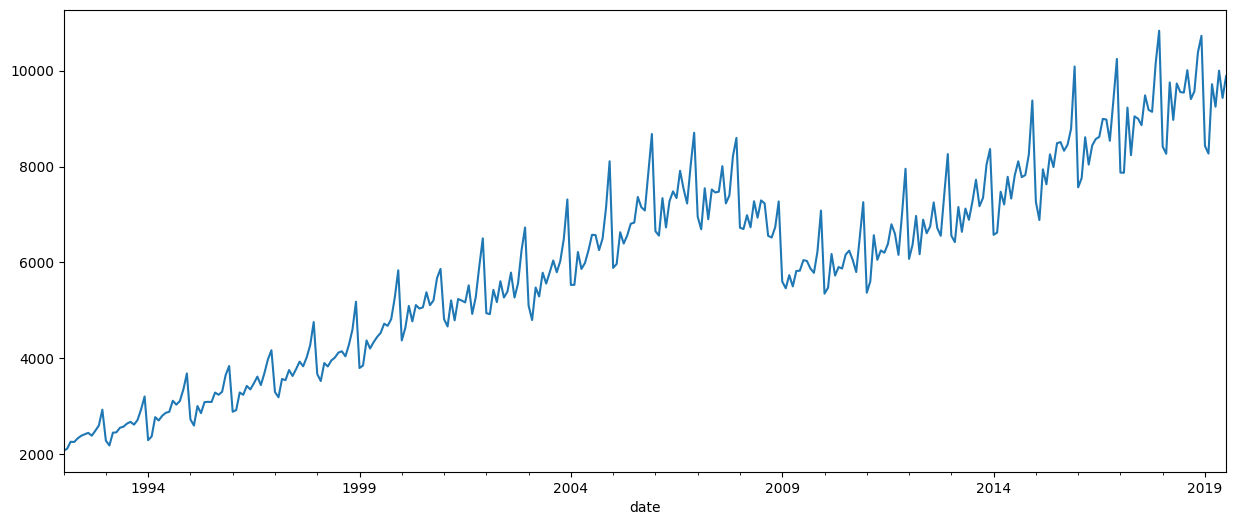

In [150]:
df["furniture_price_adjusted"].plot(figsize=(15,6));

Es una serie temporal con tendencia ascendente - excepto una bajada entre 2008 y 2011, probablemente por la crisis - y estacionalidad marcada.  
En consecuencia, NO ES ESTACIONARIA.

## 5. ¿Podrías demostrar de dos maneras estadísticas que la serie no es estacionaria?

In [151]:
from statsmodels.tsa.stattools import adfuller

stat, pval, usedlag, nobs,crtivals, icbest = adfuller(df["furniture_price_adjusted"].values) 
print(pval)

# Dickey-Fuller 0.7: no es serie estacionaria

0.7035529748089981


In [152]:
print(df["furniture_price_adjusted"].mean())
print(df["furniture_price_adjusted"].std())

5975.7657872030095
2092.867819477299


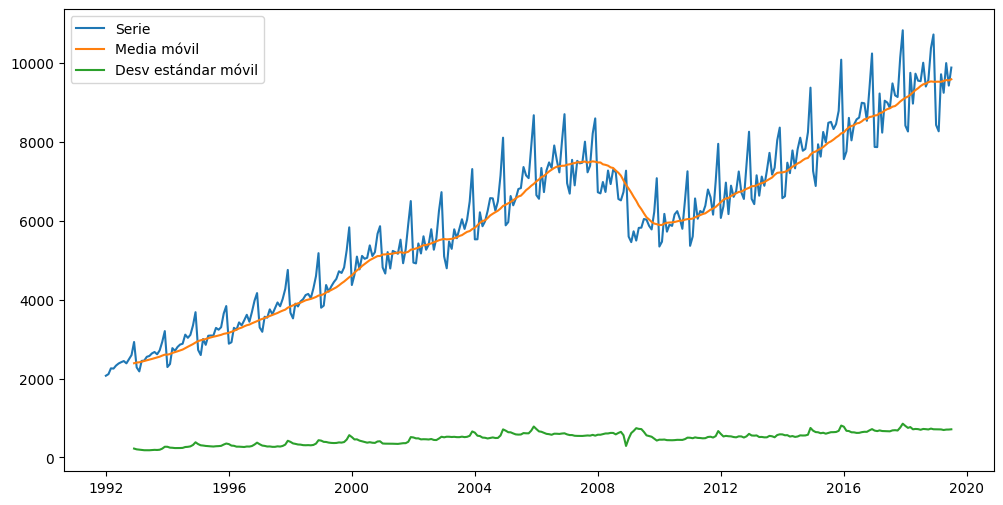

In [153]:
rolling_mean = df["furniture_price_adjusted"].rolling(window=12).mean()
rolling_std = df["furniture_price_adjusted"].rolling(window=12).std()

plt.figure(figsize=(12,6))

plt.plot(df["furniture_price_adjusted"], label="Serie")
plt.plot(rolling_mean, label="Media móvil")
plt.plot(rolling_std, label="Desv estándar móvil")

plt.legend()
plt.show()

In [154]:
# media super cambiante: no es serie estacionaria

## 6. ¿Conoces algún método para representar mejor la tendencia?
Parece que hay una tendencia, pero no se aprecia bien con tanto pico en la serie. ¿Conoces algún método para representar mejor la tendencia?

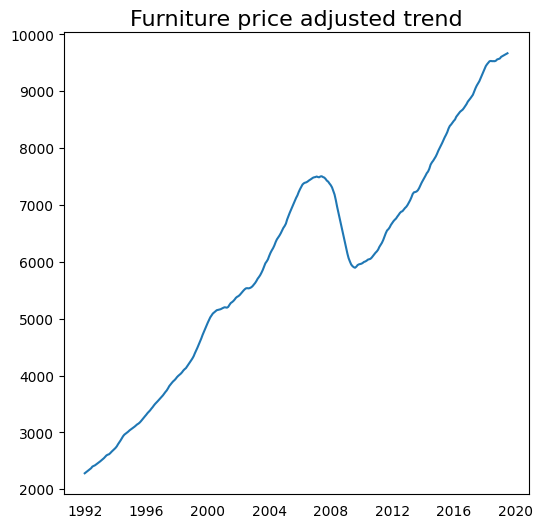

In [174]:
from statsmodels.tsa.seasonal import seasonal_decompose

result_add = seasonal_decompose(df['furniture_price_adjusted'], model='aditive', extrapolate_trend='freq')

plt.plot(result_add.trend)
plt.title('Furniture price adjusted trend', fontsize=16);

EXTRA: SEASONALITY :)

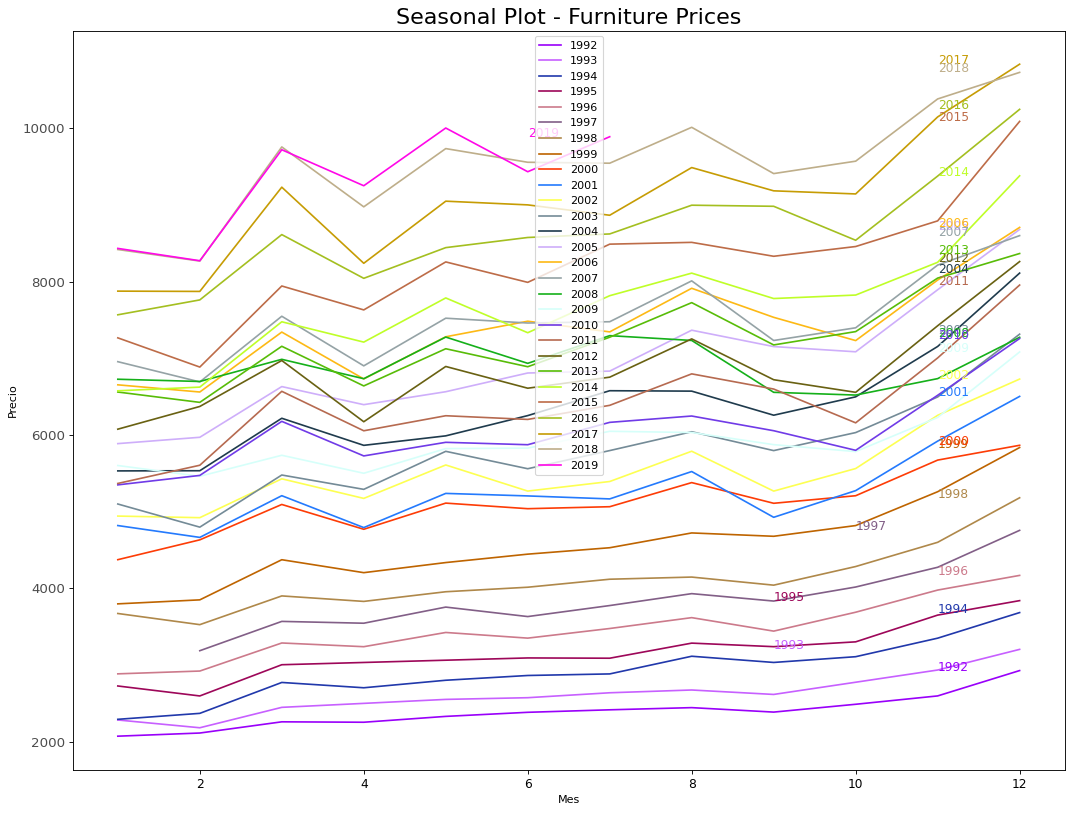

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Colores
np.random.seed(100)
mycolors = np.random.choice(
    list(mpl.colors.XKCD_COLORS.keys()),
    len(years),
    replace=False
)

# Gráfico
plt.figure(figsize=(16,12), dpi=80)

for i, y in enumerate(years):

    data = df.loc[df["year"] == y, :]

    plt.plot(
        "month",
        "furniture_price_adjusted",
        data=data,
        color=mycolors[i],
        label=y
    )

    # texto al final de cada línea
    plt.text(
        data.shape[0]-1,
        data["furniture_price_adjusted"].iloc[-1],
        y,
        fontsize=11,
        color=mycolors[i]
    )

# Decoración
plt.xlabel("Mes")
plt.ylabel("Precio")
plt.title("Seasonal Plot - Furniture Prices", fontsize=20)

plt.yticks(fontsize=12, alpha=.7)
plt.xticks(fontsize=11)

plt.legend()
plt.show();

En marzo, mayo, agosto y diciembre hay picos de ventas - especialmente diciembre, coincidiendo con Navidad.  
En febrero, abril, junio y octubre hay bastante caída.

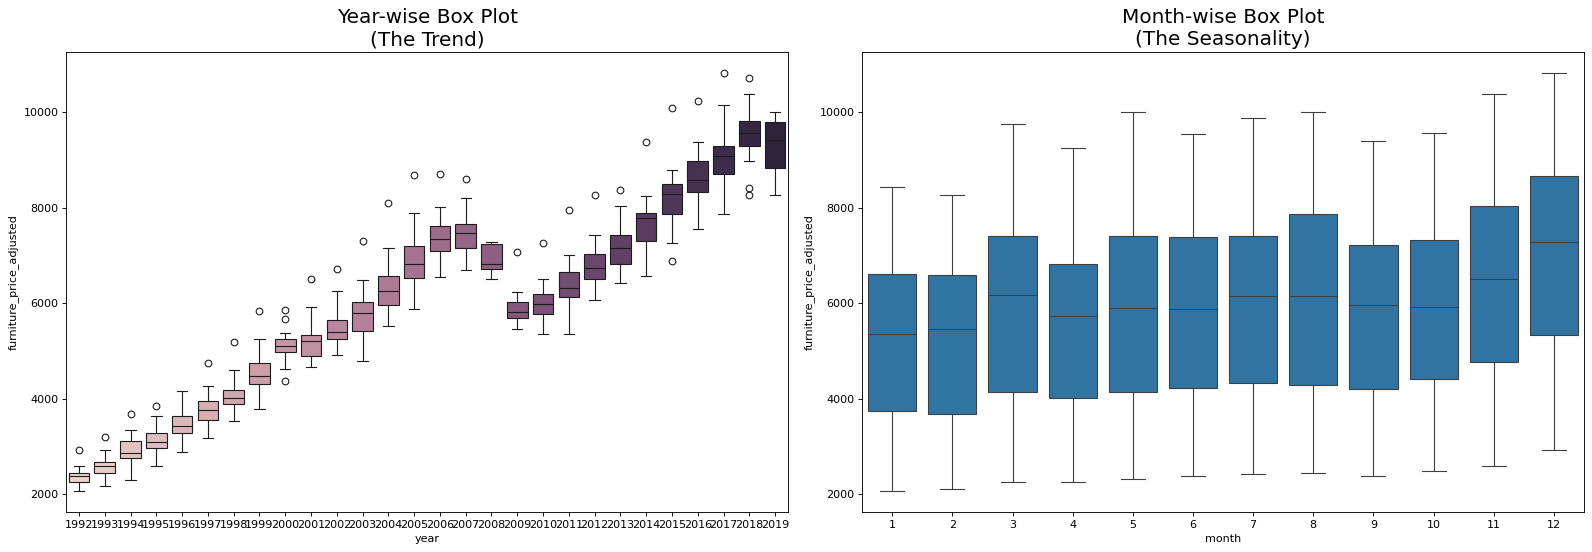

In [156]:
import seaborn as sns

# Resetear índice para tener year y month como columnas
df_plot = df.reset_index()
df_plot["year"] = df_plot["date"].dt.year
df_plot["month"] = df_plot["date"].dt.month

# Draw Plot
fig, axes = plt.subplots(1, 2, figsize=(20, 7), dpi=80)

sns.boxplot(x='year', y='furniture_price_adjusted', data=df_plot, ax=axes[0], hue='year', legend=False)
sns.boxplot(x='month', y='furniture_price_adjusted', data=df_plot.loc[~df_plot["year"].isin([1991, 2008]), :], ax=axes[1])

# Set Title
axes[0].set_title('Year-wise Box Plot\n(The Trend)', fontsize=18)
axes[1].set_title('Month-wise Box Plot\n(The Seasonality)', fontsize=18)

plt.tight_layout()
plt.show()

## 7. Estaría bien visualizar todos los componentes de la serie temporal por separado

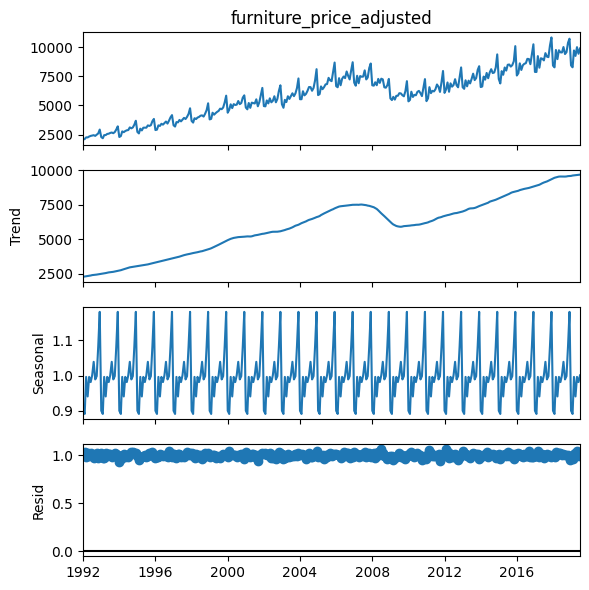

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Descomposición MULTIPLICATIVA
result_mul = seasonal_decompose(df['furniture_price_adjusted'], model = 'multiplicative', extrapolate_trend = 'freq')

plt.rcParams.update({'figure.figsize': (6,6)})
result_mul.plot();

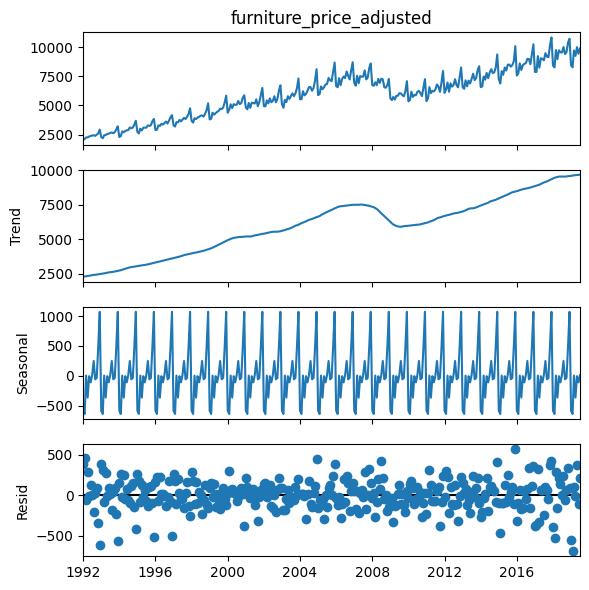

In [158]:
# Descomposición ADITIVA
result_add = seasonal_decompose(df['furniture_price_adjusted'], model = 'additive', extrapolate_trend = 'freq')

result_add.plot();

## 8. Demuestra mediante una gráfica de autocorrelación que la serie es estacional

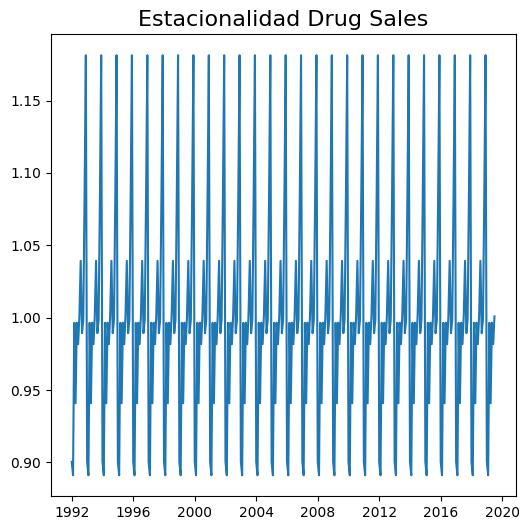

In [ ]:
# Graficamos la estacionalidad

plt.plot(result_mul.seasonal)
plt.title('Estacionalidad Drug Sales', fontsize=16);

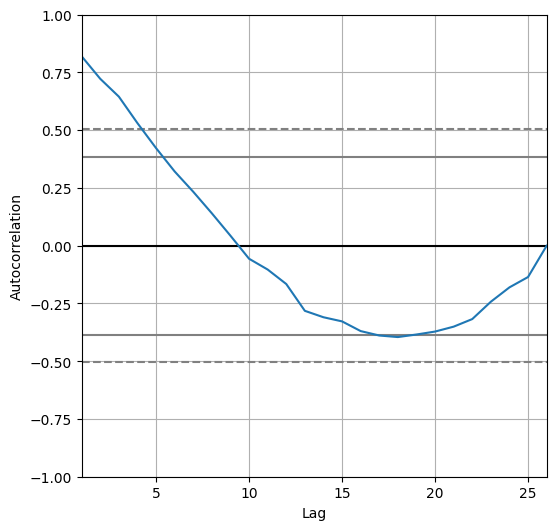

In [ ]:
from statsmodels.tsa.stattools import acf
from pandas.plotting import autocorrelation_plot

acf_vals = acf(df.furniture_price_adjusted.values)
autocorrelation_plot(acf_vals);

# no lo entiendo bien

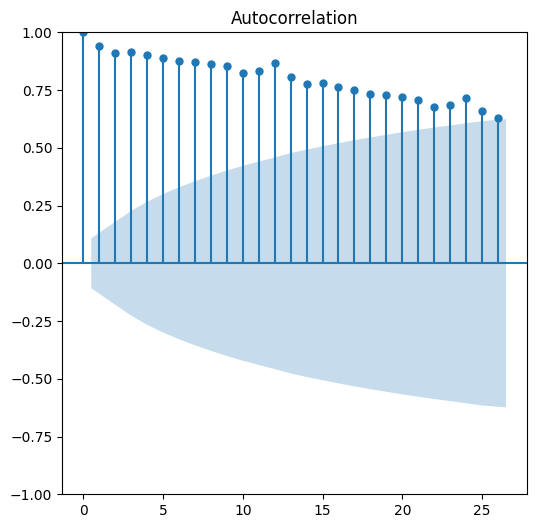

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df.furniture_price_adjusted.values);

# en el 12 y 24 se ve cómo el chupachups sube --> el valor actual está muy relacionado con el de los años anteriores en el mismo mes

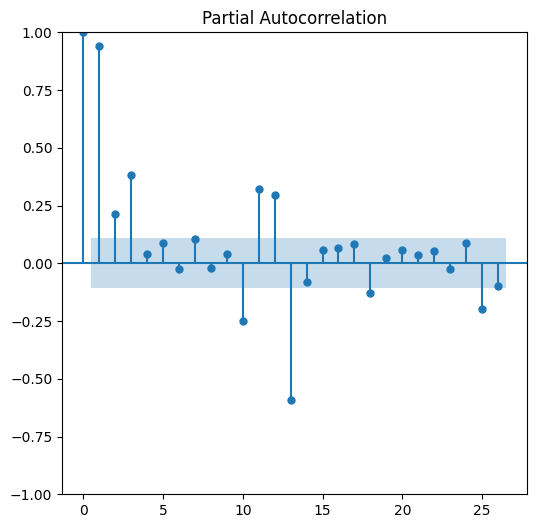

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df.furniture_price_adjusted.values);

# este no lo entiendo mucho tampoco

## 9. ¿Qué dependencia tiene cada instante de sus últimos 5 lags? Demuéstralo mediante una matriz de correlación.

In [167]:
df2 = df.copy()
emb_size = 5 # Pasos = lags

for i in range(1, emb_size+1):
    df2['lag' + str(i)] = df2['furniture_price_adjusted'].shift(i)

In [170]:
df2.drop(["year", "month", "day"], axis=1, inplace=True)
df2.reset_index(drop=True, inplace=True)
df2

# el dato y sus 5 instantes anteriores

,furniture_price_adjusted,lag1,lag2,lag3,lag4,lag5
0,2384.638567,2331.414618,2255.103236,2260.570891,2114.485812,2073.432724
1,2417.165376,2384.638567,2331.414618,2255.103236,2260.570891,2114.485812
2,2445.498729,2417.165376,2384.638567,2331.414618,2255.103236,2260.570891
3,2387.351705,2445.498729,2417.165376,2384.638567,2331.414618,2255.103236
4,2489.350838,2387.351705,2445.498729,2417.165376,2384.638567,2331.414618
...,...,...,...,...,...,...
316,9718.107698,8271.237355,8431.965334,10726.595075,10380.194097,9569.037851
317,9248.814254,9718.107698,8271.237355,8431.965334,10726.595075,10380.194097
318,10001.305304,9248.814254,9718.107698,8271.237355,8431.965334,10726.595075
319,9431.337229,10001.305304,9248.814254,9718.107698,8271.237355,8431.965334


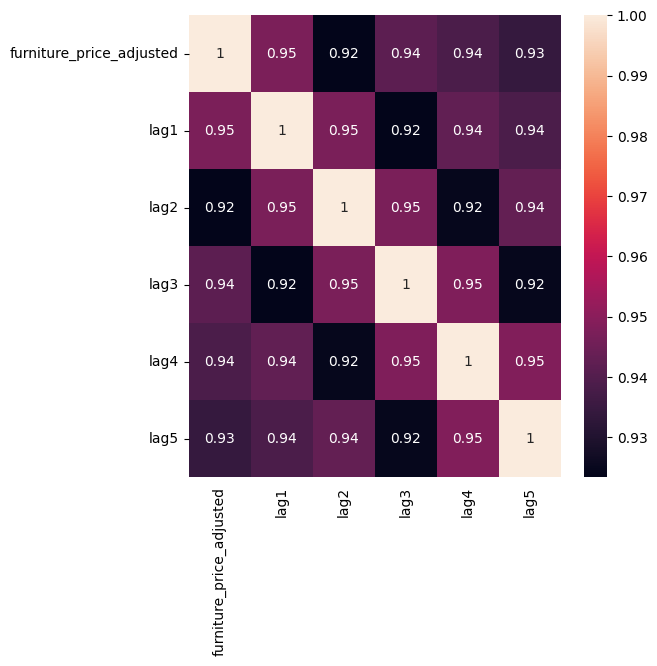

In [175]:
import seaborn as sns

sns.heatmap(df2.corr(), annot=True);

## 10. Ya hemos visto que hay estacionalidad. ¿Cada cuántos instantes se cumple ese patrón?

In [ ]:
# el patrón se cumple cada 12 instantes; es decir, el mes de diciembre de este año está relacionado con el del año pasado, y el del anterior...

## 11. Para un futuro modelado de los datos necesitaremos eliminar la tendencia. ¿Cómo hacemos esto?

* Opción 1: medias móviles

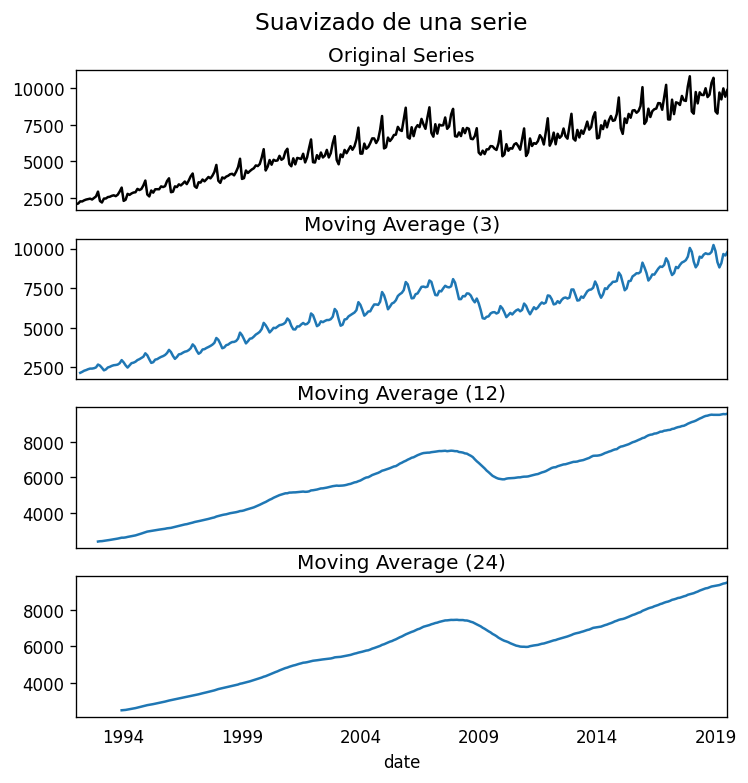

In [171]:
plt.rcParams.update({'xtick.bottom' : False, 'axes.titlepad':5})

df_ma = df.furniture_price_adjusted.rolling(3).mean() # de los 3 puntos anteriores
df_ma_12 = df.furniture_price_adjusted.rolling(12).mean() # de los 12 puntos anteriores - los periodos donde suben y bajan se compensan, es una tendencia
# en enero coge la media de los 12 meses anteriores; en febrero coge enero y los 11 meses del año anterior; en marzo coge febrero, enero y los 10 meses del año anterior...
df_ma_24 = df.furniture_price_adjusted.rolling(24).mean() # de los 24 puntos anteriores - dos veces ese periodo, aún más suavizada

# Plot
fig, axes = plt.subplots(4,1, figsize=(7, 7), sharex=True, dpi=120)
df['furniture_price_adjusted'].plot(ax=axes[0], color='k', title='Original Series')
df_ma.plot(ax=axes[1], title='Moving Average (3)')
df_ma_12.plot(ax=axes[2], title='Moving Average (12)')
df_ma_24.plot(ax=axes[3], title='Moving Average (24)')
fig.suptitle('Suavizado de una serie', y=0.95, fontsize=14)
plt.show();

* Opción 2: LOWESS

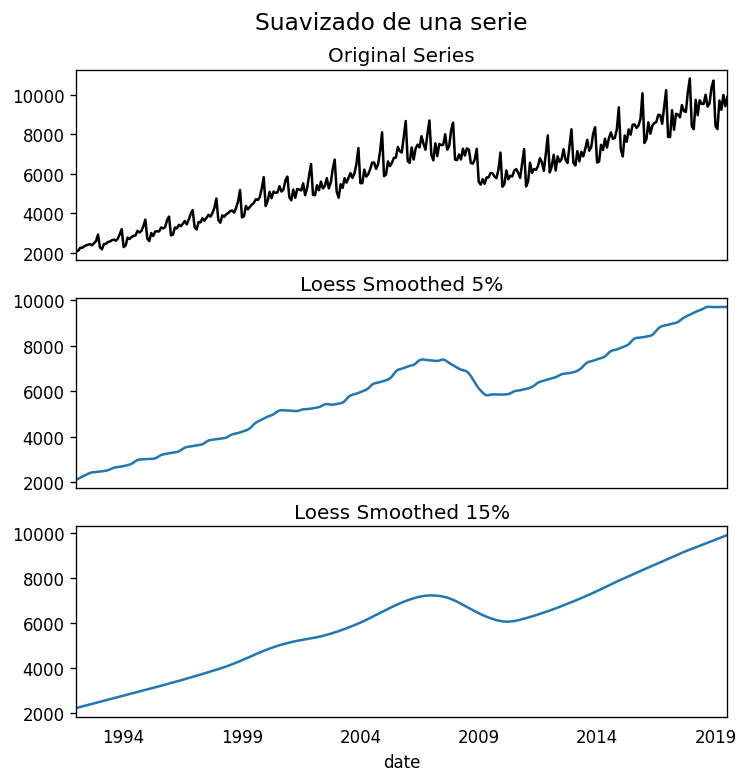

In [173]:
from statsmodels.nonparametric.smoothers_lowess import lowess

# Loess Smoothing (5% and 15%)
df_loess_5 = pd.DataFrame(lowess(df.furniture_price_adjusted, np.arange(len(df.furniture_price_adjusted)), frac=0.05)[:, 1], index=df.index, columns=['furniture_price_adjusted'])
df_loess_15 = pd.DataFrame(lowess(df.furniture_price_adjusted, np.arange(len(df.furniture_price_adjusted)), frac=0.15)[:, 1], index=df.index, columns=['furniture_price_adjusted'])

# Plot
fig, axes = plt.subplots(3,1, figsize=(7, 7), sharex=True, dpi=120)
df['furniture_price_adjusted'].plot(ax=axes[0], color='k', title='Original Series')
df_loess_5['furniture_price_adjusted'].plot(ax=axes[1], title='Loess Smoothed 5%') # suavizado del 5%
df_loess_15['furniture_price_adjusted'].plot(ax=axes[2], title='Loess Smoothed 15%') # suavizado del 15% - confianza de que hemos cogido la tendencia
fig.suptitle('Suavizado de una serie', y=0.95, fontsize=14)
plt.show();